<a href="https://colab.research.google.com/github/Aryan-Gupta2002/Deep-Learning---Tensorflow/blob/main/neuralNetworkForClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###This notebook is to study about the classification models of Deep Learning with Neural Networks
------
**Classification is an algorithm which classifies which class a particular sample belongs to.** (eg: if an email belongs to Spam class or Not Spam Class)  
Types of Classification:-   
•Binary Classification  
•Multiclass Classification  
•Multilabel Classification

###Basic Architecture of Classification Model
----
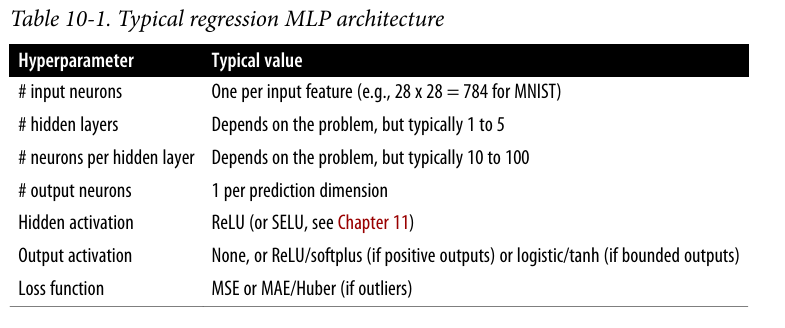


#Creating Dataset to view and fit

In [1]:
from sklearn.datasets import make_circles
# Making 1000 samples
n_samples = 1000

# Creating Circles
x,y=make_circles(n_samples,
                 noise=0.03,
                 random_state=42)

In [2]:
# Checking out features and labels
x,y[:10]

(array([[ 0.75424625,  0.23148074],
        [-0.75615888,  0.15325888],
        [-0.81539193,  0.17328203],
        ...,
        [-0.13690036, -0.81001183],
        [ 0.67036156, -0.76750154],
        [ 0.28105665,  0.96382443]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

Our data is little hard to understand, let's visualize it

In [3]:
import pandas as pd
circles = pd.DataFrame({"X0":x[:,0],"X1":x[:,1],"labels":y})
circles

,X0,X1,labels
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


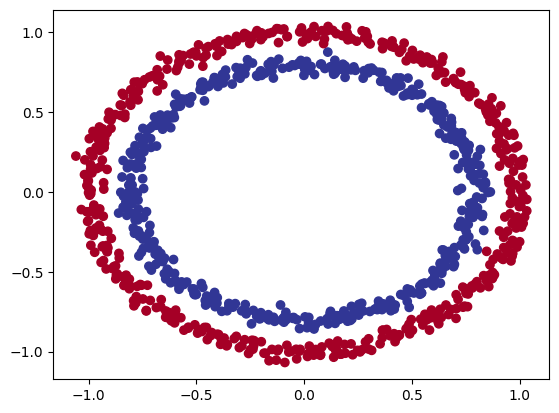

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x[:,0],x[:,1],c=y, cmap=plt.cm.RdYlBu)

In [5]:
# checking shapes of our features and labels
x.shape,y.shape,len(x),len(y)

((1000, 2), (1000,), 1000, 1000)

## Steps in Modelling
----
1.Create or import a model  
2.Compile the model  
3.Fit the model  
4.Evaluate the model  
5.Tweak  
6.Evaluate

In [6]:
import tensorflow as tf

In [7]:
#Setting seed
tf.random.set_seed(42)
# Model Building
model_1=tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])
# Compiling Model
model_1.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer = tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)
#Fitting with data
model_1.fit(x,y,epochs=5)


Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5235 - loss: 5.9843
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5195 - loss: 5.7979
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4980 - loss: 4.9284
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5172 - loss: 1.3947
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5179 - loss: 0.7123


In [8]:
# Let's try to improve our model
model_1.fit(x,y,epochs=5,verbose=0)
model_1.evaluate(x,y) # it is not right to evaluate on same traininig data

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4955 - loss: 0.6932


[0.6932143568992615, 0.5]

Since we're working on a binary classification problem and our model is getting around 50% accuracy. It's basically guessing and not actually learning

In [9]:
# Let's try adding an extra layer
tf.random.set_seed(42)
model2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1),
])
model2.compile(
    loss = tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)
model2.fit(x,y,epochs=200,verbose=0)
model2.evaluate(x,y) # not much happened, results are similar

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4955 - loss: 0.6931


[0.6933144330978394, 0.5]

## Improving the model  
We can do perform follwing updates to check if our model improves   
1. Create a model - we might add layers or increase the number of hidden units within a layer  
2. Compiling a model - here we might choose a different optimization function such as ADAM instead of SGD    
3. Fitting a model- perhaps we might fit our model for more epochs for longer learning period


In [10]:
# This time let's try to add one exrtra layer with more neurons.
tf.random.set_seed(42)
model3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
model3.compile(
    loss=tf.keras.losses.BinaryCrossentropy,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
model3.fit(x,y,epochs=200,verbose=0)


In [11]:
model3.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4948 - loss: 0.6919


[0.693947434425354, 0.4819999933242798]

At this point we can notice that the model is not improving at all. The adjustment of the above hyperparameters seemed to work in case of regression model training

To Visualize our model's prediction , let's create a function **"plot_decision-boundary"**,this function will:   

*Take in a trained model, feature (x) and labels (y)  
*Create a meshgrid of the different x values   
*Make predictions across the meshgrid  
*Plot the predictions as well as a line between zones (where each unique class falls)  
**NOTE:** Study about Meshgrid    
link-https://www.geeksforgeeks.org/python/numpy-meshgrid-function/

In [12]:
import numpy as np

Resource: https://cs231n.github.io/

In [13]:
def plot_decision_boundary(model,x,y):
  """Plot the decision boundary created by a model predicting on X"""
  #Define the axis boundaries of the plot and create a meshgrid
  x_min,x_max = x[:,0].min()-0.1,x[:,0].max()+0.1
  y_min,y_max=x[:,1].min()-0.1,x[:,1].max()+0.1
  xx,yy=np.meshgrid(np.linspace(x_min,x_max,100),
                    np.linspace(y_min,y_max,100))

  #Create x value (we're going to make predictions on these)
  x_in = np.c_[(xx.ravel(),yy.ravel())] # stack 2D arrays together

  #Make predictions
  y_pred = model.predict(x_in)

  #Check for multi-class
  if len(y_pred[0])>1:
    print("doing multiclass classification")
    # We have to reshape our predictions to get them ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
  else:
    print("Doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  # Plot the decision boundary
  plt.contourf(xx,yy,y_pred,cmap=plt.cm.RdYlBu,alpha=0.7)
  plt.scatter(x[:,0],x[:,1],c=y,s=40,cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min(),xx.max())
  plt.ylim(yy.min(),yy.max())

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


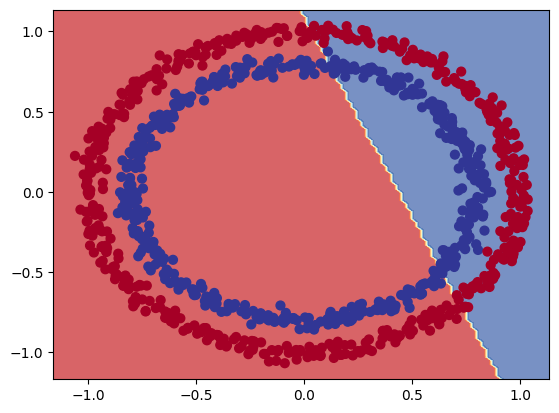

In [14]:
# Let's try decision boundary
plot_decision_boundary(model3,x,y)

Explanation  : So our model3 is trained and put to set with our classification dataset. The model3 is a linear model which draws a line to predict the outputs. However, in our current dataset, we have two circles, one inside another, and our model is trying to plot a line with least loss. However, a straight line model cannot classify and perform well on our current dataset.

In [15]:
# Let's try the model for regression model
x_reg = tf.range(0,1000,5)
x_reg = tf.expand_dims(x_reg, axis=-1)
y_reg = tf.range(100,1100,5)


#Splitting
x_reg_train= x_reg[:150]
x_reg_test = x_reg[150:]
y_reg_train= y_reg[:150]
y_reg_test = y_reg[150:]


In [16]:
x_reg_train.shape,y_reg_train.shape

(TensorShape([150, 1]), TensorShape([150]))

In [17]:
tf.random.set_seed(42)
model3= tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])
model3.compile(
    loss= tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)
model3.fit(x_reg_train,y_reg_train,epochs=100)
model3.evaluate(x_reg_test,y_reg_test)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 149ms/step - loss: 684.9523 - mae: 684.9523
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 542.3273 - mae: 542.3273 
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 400.3387 - mae: 400.3387 
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 257.2677 - mae: 257.2677 
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 112.1759 - mae: 112.1759 
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 62.3491 - mae: 62.3491  
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 98.3849 - mae: 98.3849   
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 74.0138 - mae: 74.0138 
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 43.9415 - mae: 43.9415 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 52.5916 - mae: 52.5916 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 41.3316 - mae: 41.3316 
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 46.2406 - mae: 46.2406 
Epoch 13/10

[64.2341079711914, 64.2341079711914]

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


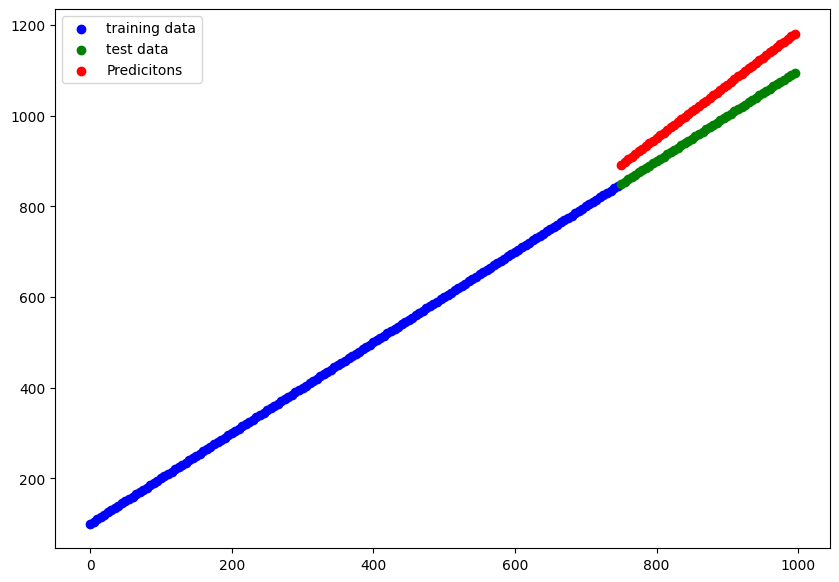

In [18]:
y_reg_pred=model3.predict(x_reg_test) # PRedictions

#Plotting model's predictions
plt.figure(figsize=(10,7))
plt.scatter(x_reg_train,y_reg_train, c='b', label="training data")
plt.scatter(x_reg_test,y_reg_test,c='g',label="test data")
plt.scatter(x_reg_test,y_reg_pred,c='r',label="Predicitons")
plt.legend();

#ReLU (Rectified Linear Unit) is defined as:

𝑓(𝑥)=max(0,𝑥)  
f(x)=max(0,x)

That means:

if
𝑥
<
0
x<0 → output = 0

if
𝑥
≥
0
x≥0 → output = x

##Adding Non-linearity to a linearly inseparable dataset.  
Non-linear activations- Relu, Sigmoid, Tan

In [19]:
x.shape,y.shape

((1000, 2), (1000,))

In [20]:
#Using Relu non-linear activation for our dataset
tf.random.set_seed(42)
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1),
])
model4.compile(
    loss = "binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history = model4.fit(x,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.4830 - loss: 4.2089
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 3.3705
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 3.1492
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 3.0909
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 3.0539
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 3.0300
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 2.9933
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 2.9652
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 2.9060
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 2.8447
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4830 - loss: 2.7976
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [21]:
model4.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5940 - loss: 0.6367


[0.6429839730262756, 0.5920000076293945]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


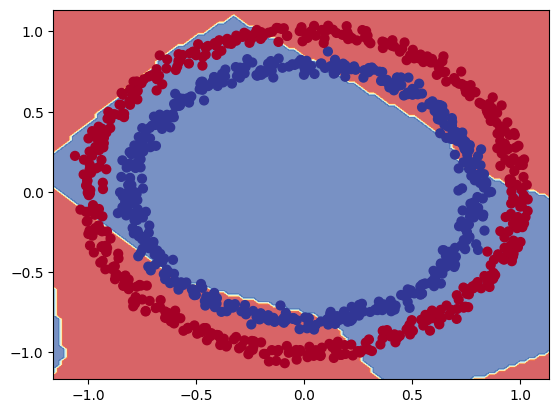

In [22]:
plot_decision_boundary(model4,x,y)

### Our model did not perform good above but we have not yet tried output layer activation.   
### Let's try sigmoid (for binary classification) as output layer activation. Softmax( for multi class classification)

In [23]:
#Using Relu non-linear activation for our dataset
tf.random.set_seed(42)
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation ="sigmoid")
])
model4.compile(
    loss = "binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)
history = model4.fit(x,y,epochs=100)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4765 - loss: 0.7553
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4965 - loss: 0.7194
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5012 - loss: 0.7002
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4964 - loss: 0.6918
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5156 - loss: 0.6880
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5133 - loss: 0.6861
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5246 - loss: 0.6849
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5207 - loss: 0.6839
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5271 - loss: 0.6831
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5329 - loss: 0.6823
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5299 - loss: 0.6816
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy

In [24]:
model4.evaluate(x,y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8376 - loss: 0.4821


[0.48435017466545105, 0.8299999833106995]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification


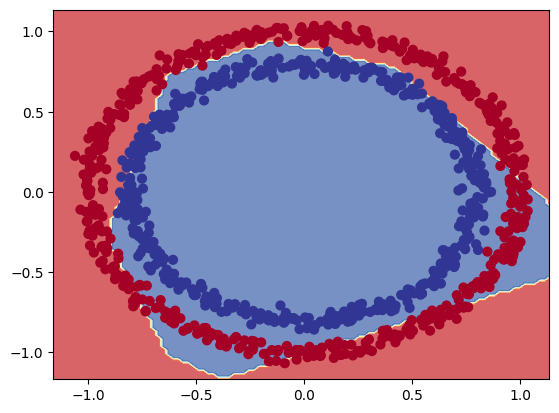

In [25]:
plot_decision_boundary(model4,x,y)

A sigmoid is an activation function which takes in inputs and return 0 or 1 as output, that is why is used for binary classification.   
Now we will convert a straight line to a non-linear using sigmoid

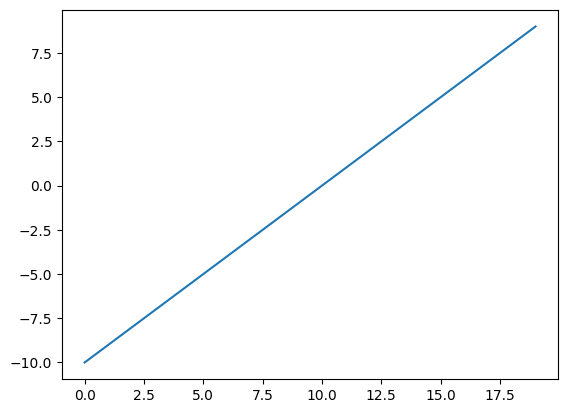

In [26]:
A = tf.cast(tf.range(-10,10), tf.float32)
plt.plot(A)

In [27]:
def sigmoid(x):
    return 1/(1+tf.exp(-x))
sigmoid(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([4.5397868e-05, 1.2339458e-04, 3.3535014e-04, 9.1105117e-04,
       2.4726230e-03, 6.6928510e-03, 1.7986210e-02, 4.7425874e-02,
       1.1920292e-01, 2.6894143e-01, 5.0000000e-01, 7.3105854e-01,
       8.8079703e-01, 9.5257413e-01, 9.8201376e-01, 9.9330717e-01,
       9.9752742e-01, 9.9908900e-01, 9.9966466e-01, 9.9987662e-01],
      dtype=float32)>

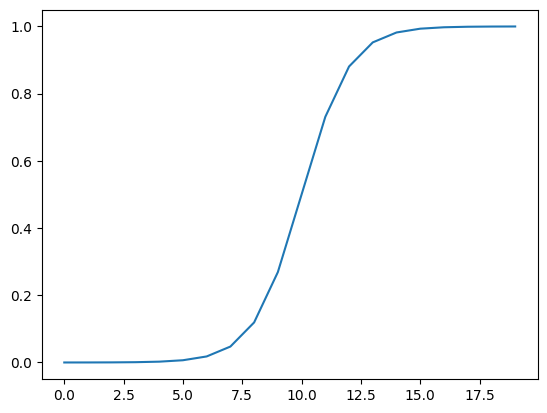

In [28]:
plt.plot(sigmoid(A))

In [29]:
# Creating relu function
def relu(x):
    return tf.maximum(0,x)
relu(A)

<tf.Tensor: shape=(20,), dtype=float32, numpy=
array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6.,
       7., 8., 9.], dtype=float32)>

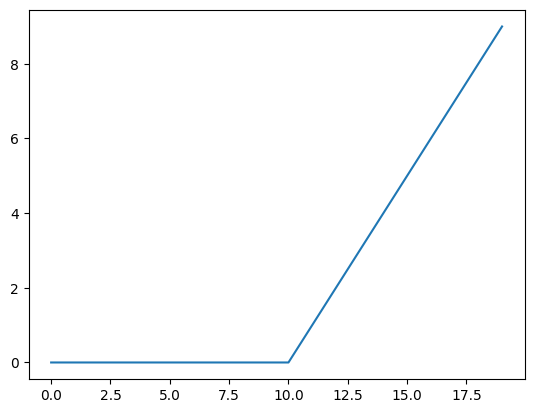

In [30]:
plt.plot(relu(A))

In [31]:
len(x)

1000

In [32]:
from sklearn.model_selection import train_test_split

In [33]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [34]:
# This time let's see the effect of learning rate on our model
tf.random.set_seed(42)
model5 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])
model5.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),
    metrics=["accuracy"]
)
history3 = model5.fit(x,y,epochs= 25)

Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5127 - loss: 0.6934
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5076 - loss: 0.6907
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5317 - loss: 0.6849
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5515 - loss: 0.6780
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5584 - loss: 0.6670
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6567 - loss: 0.6435
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7146 - loss: 0.5920
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8075 - loss: 0.5304
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8332 - loss: 0.4608
Epoch 10/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9155 - loss: 0.3855
Epoch 11/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9506 - loss: 0.3144
Epoch 12/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9670 - l

### model.fit() returns A History object. Its History.history attribute is a record of training loss values and metrics values at successive epochs, as well as validation loss values and validation metrics values (if applicable).

In [35]:
model5.evaluate(x_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9904 - loss: 0.0498


[0.0592477023601532, 0.9900000095367432]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Doing binary classification


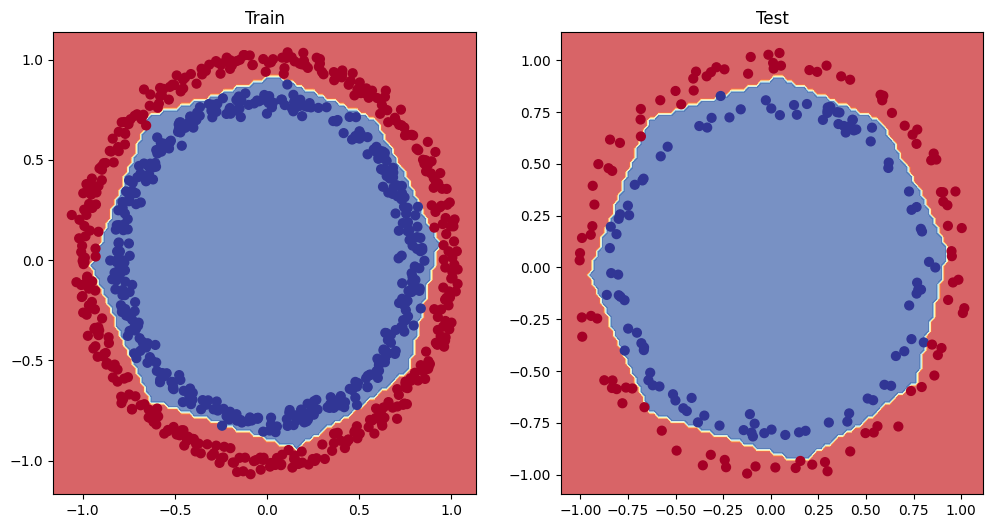

In [36]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model5,x_train,y_train)
plt.subplot(1,2,2)   # Keep indexing in mind
plt.title("Test")
plot_decision_boundary(model5,x_test,y_test)
plt.show()

# Plotting the loss (training) curve of our model

In [37]:
pd.DataFrame(history3.history)

,accuracy,loss
0,0.506,0.693631
1,0.499,0.689996
2,0.520,0.685660
3,0.533,0.678605
4,0.554,0.667004
5,0.647,0.631756
6,0.745,0.576043
7,0.818,0.510464
8,0.860,0.439198
9,0.928,0.362517


Text(0.5, 1.0, 'Loss Curve')

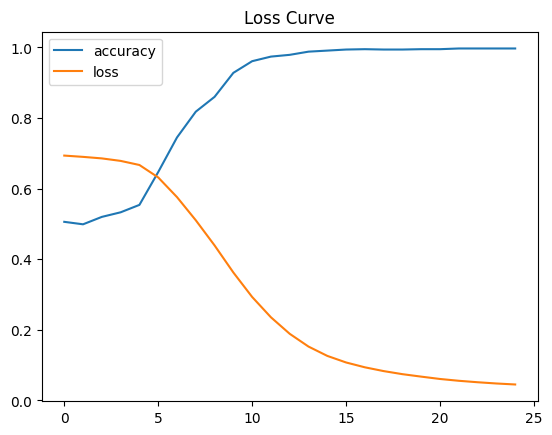

In [38]:
# Plotting the loss curve
pd.DataFrame(history3.history).plot()
plt.title("Loss Curve")

#Callbacks function:   
https://www.kdnuggets.com/2019/08/keras-callbacks-explained-three-minutes.html

## Finding the best Learning rate  

To find the best learning rate (the lr where loss decreases the most) we are going to use the following steps:  
* A learning rate **callback** - you can think of a callback as an extra piece of functionality , we can add to our model while training.  
* Another Model - We will practice on newer models.
* A modified loss curve plot.

In [39]:
tf.random.set_seed(42)
model6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])
model6.compile(
    loss = "binary_crossentropy",
    optimizer ="Adam",
    metrics=["accuracy"]
)
#Important : Creating a learning rate callback
lr_scheduler = tf.keras.callbacks.LearningRateScheduler(lambda epoch : 1e-4 * 10**(epoch/20))
history4=model6.fit(
    x_train,
    y_train,
    epochs=100,
    callbacks=[lr_scheduler]
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5025 - loss: 0.6916 - learning_rate: 1.0000e-04
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.6912 - learning_rate: 1.1220e-04
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.6907 - learning_rate: 1.2589e-04
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.6902 - learning_rate: 1.4125e-04
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.6897 - learning_rate: 1.5849e-04
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5025 - loss: 0.6892 - learning_rate: 1.7783e-04
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5025 - loss: 0.6886 - learning_rate: 1.9953e-04
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5028 - loss: 0.6881 - learning_rate: 2.2387e-04
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5032 - loss: 0.6874 - learning

<Axes: xlabel='epochs'>

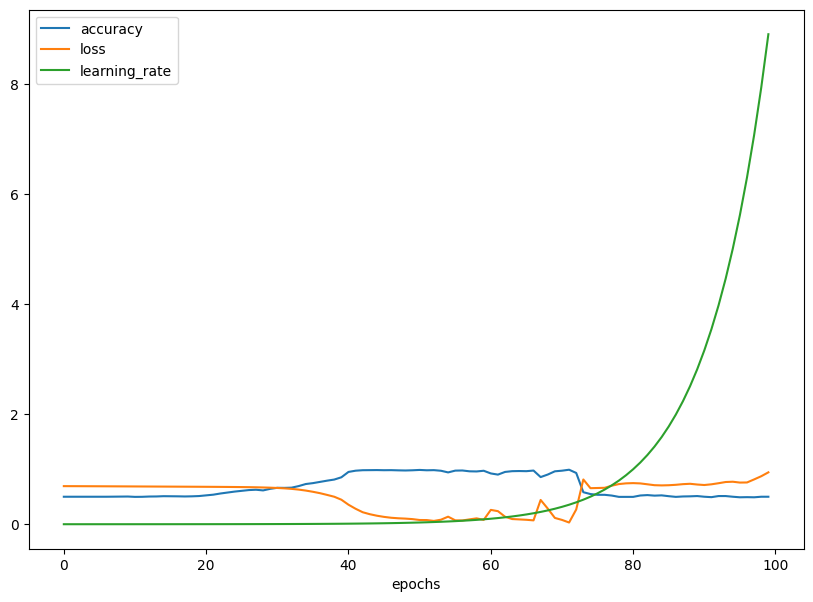

In [40]:
pd.DataFrame(history4.history).plot(figsize=(10,7),xlabel="epochs")

We will be using plt.semilogx().Read about it.  
https://www.geeksforgeeks.org/python/matplotlib-pyplot-semilogx-in-python/

Text(0.5, 1.0, 'Learning rate vs Loss')

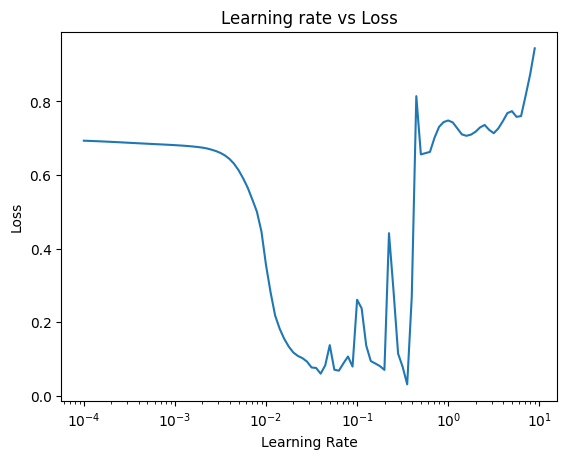

In [41]:
# Plotting the learning rate vs loss
lrs = 1e-4 * (10**(tf.range(100)/20))
plt.semilogx(lrs,history4.history["loss"])
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Learning rate vs Loss")

Generally, the ideal learning rate is somewhere between the lowest point of the graph and ten times smaller value than the lowest point

We observe that loss is decreasing at 0.02 the fastest

In [46]:
# Using LR as 0.02
tf.random.set_seed(42)
model7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(4,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")
])
model7.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate = 0.02),
    metrics=["accuracy"]
)
history5 = model7.fit(x,y,epochs= 20)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4826 - loss: 0.6971
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5429 - loss: 0.6838
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6288 - loss: 0.6602
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7059 - loss: 0.6176
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7502 - loss: 0.5488
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8416 - loss: 0.4395
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9432 - loss: 0.3089
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9794 - loss: 0.1938
Epoch 9/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9888 - loss: 0.1333
Epoch 10/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9899 - loss: 0.1043
Epoch 11/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9912 - loss: 0.0814
Epoch 12/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9912 - l

Model5 (LR=0.01, Epochs 25 ):accuracy: 0.9961 - loss: 0.0365   
Model7 (LR=0.02, Epochs 20 ):accuracy: 0.9908 - loss: 0.0332


In [47]:
model5.evaluate(x_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9904 - loss: 0.0498 


[0.0592477023601532, 0.9900000095367432]

In [48]:
model7.evaluate(x_test,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9963 - loss: 0.0336


[0.03473559394478798, 0.9950000047683716]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Doing binary classification
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Doing binary classification


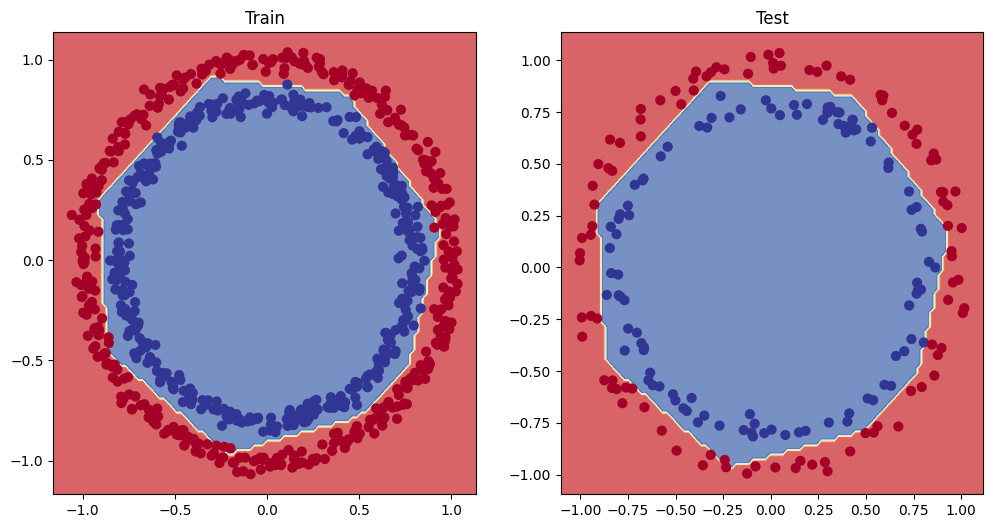

In [49]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model7,x_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model7,x_test,y_test)
plt.show()

##More Classification Evaluation Metrics
* Accuracy  
* Precision  
* Recall  
* F1-Score  
* Confusion Matrix  
* Classification Report

In [50]:
# Creating a confusion matrix
from sklearn.metrics import  confusion_matrix

y_pred = model7.predict(x_test)
confusion_matrix(y_test,y_pred)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


ValueError: Classification metrics can't handle a mix of binary and continuous targets

In [51]:
y_test[:10]

array([1, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [52]:
y_pred[:10]

array([[9.9701887e-01],
       [2.3951421e-03],
       [9.9892229e-01],
       [1.4660589e-02],
       [9.9515516e-01],
       [9.8670685e-01],
       [8.5010302e-05],
       [2.9375777e-03],
       [9.9886441e-01],
       [6.6991337e-04]], dtype=float32)

ValueError, type mismatch occured

In [56]:
# Converting predictions probabilities to binary form
tf.round(y_pred)[:10]

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[1.],
       [0.],
       [1.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.]], dtype=float32)>

In [57]:
confusion_matrix(y_test,tf.round(y_pred))

array([[ 99,   1],
       [  0, 100]])